# Integração PIB + PAM + PPM — insights e transformação

## Problema e pergunta central

**Problema:** Os municípios cearenses apresentam trajetórias distintas de transformação agropecuária ao longo das últimas duas décadas, tanto em sua composição produtiva quanto na importância da agropecuária para a economia local.

**Pergunta central:** Como o perfil agropecuário dos municípios cearenses se transformou entre 2003 e 2024 e como essas mudanças se relacionam com sua estrutura econômica?

O cruzamento reproduzível das 3 bases (chave, cardinalidade, correspondência/não-correspondência) está em `cruzamento_pib_pam_ppm.ipynb`. Este notebook carrega o resultado desse cruzamento (`dados/processed/`) e foca nos insights, visualizações e na tabela final em `analytical`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

AZUL = "#0B5FA5"
LARANJA = "#F28E2B"

## 1. Carga do cruzamento já processado

In [2]:
merge_final = pd.read_parquet("../dados/processed/cruzamento_pib_pam_ppm.parquet")
valor_producao_mun = pd.read_parquet("../dados/processed/pam_valor_producao_produto.parquet")

merge_final.shape, valor_producao_mun.shape

((4048, 13), (28336, 4))

## 2. Duas visualizações preliminares (cruzamento entre bases)

**Visualização 1 — Participação % da agropecuária no VAB vs. valor da produção agrícola, municípios (2021, único ano com as 3 bases completas e sem lacuna de VAB)**

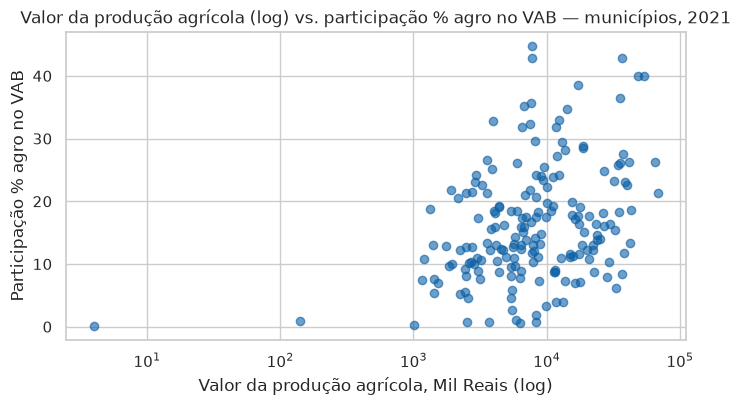

np.float64(0.3298721125393836)

In [3]:
completo_2021 = merge_final[
    (merge_final["ano_codigo"] == 2021) &
    merge_final["em_pib"] & merge_final["em_pam"] & merge_final["em_ppm"]
]

plt.scatter(completo_2021["valor_producao_agricola_total"], completo_2021["participacao_agro"], alpha=0.6, color=AZUL)
plt.xscale("log")
plt.title("Valor da produção agrícola (log) vs. participação % agro no VAB — municípios, 2021")
plt.xlabel("Valor da produção agrícola, Mil Reais (log)")
plt.ylabel("Participação % agro no VAB")
plt.show()

completo_2021["valor_producao_agricola_total"].corr(completo_2021["participacao_agro"], method="spearman")

Interpretação preliminar: se a correlação de Spearman for positiva e moderada/forte, municípios que produzem mais valor agrícola tendem a ter o VAB mais dependente de agropecuária — associação, não causa (o VAB pode ser mais dependente de agro justamente por o município ser pequeno em outros setores, não necessariamente porque produz muito).

**Visualização 2 — Efetivo bovino vs. participação % agro no VAB, municípios (2021)**

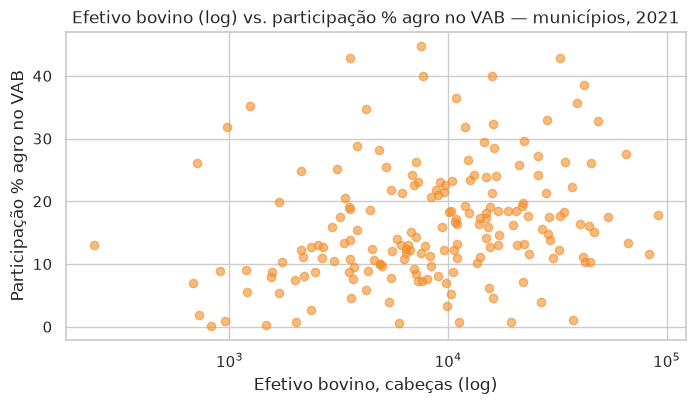

np.float64(0.3074438784626477)

In [4]:
plt.scatter(completo_2021["efetivo_bovino"], completo_2021["participacao_agro"], alpha=0.6, color=LARANJA)
plt.xscale("log")
plt.title("Efetivo bovino (log) vs. participação % agro no VAB — municípios, 2021")
plt.xlabel("Efetivo bovino, cabeças (log)")
plt.ylabel("Participação % agro no VAB")
plt.show()

completo_2021["efetivo_bovino"].corr(completo_2021["participacao_agro"], method="spearman")

Interpretação preliminar: mesma leitura de cuidado — efetivo bovino grande não implica necessariamente alta participação % (município pode ter efetivo grande e VAB total ainda maior por outros setores). Ambas as visualizações são exploratórias, pra validar que o cruzamento produz dado utilizável — os insights finais (mínimo 4, 2 cruzados) ficam pra próxima etapa.

## 3. Correlação entre indicadores (2021)

Correlação mostra só se 2 indicadores "andam juntos" — NÃO prova que um causa o outro (pode ser efeito de um terceiro fator escondido, como o tamanho geral do município). Usa o mesmo recorte `completo_2021` (único ano com as 3 bases completas e sem lacuna de VAB). Pearson mede relação linear; Spearman mede relação monotônica (sobe/desce junto, não precisa ser reta) — divergência grande entre os dois é indício de relação não-linear.

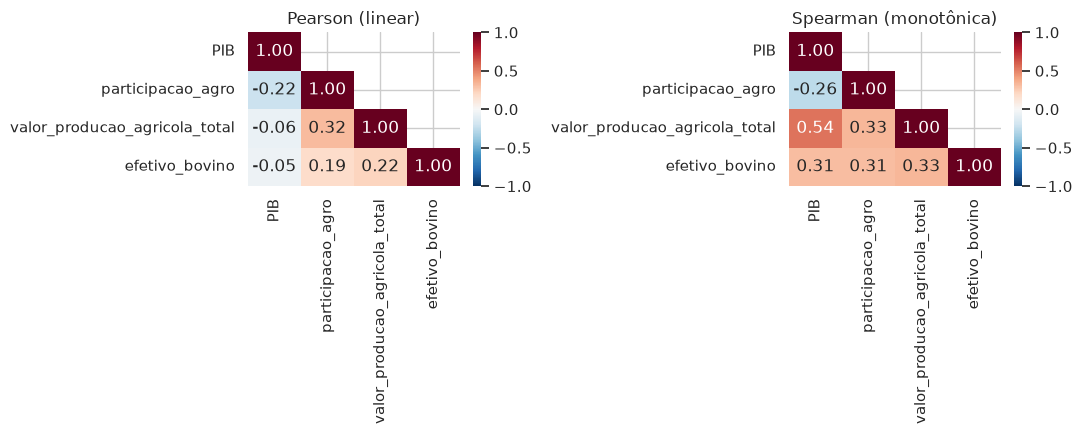

In [5]:
colunas_indicadores = ["PIB", "participacao_agro", "valor_producao_agricola_total", "efetivo_bovino"]

corr_pearson = completo_2021[colunas_indicadores].corr(method="pearson")
corr_spearman = completo_2021[colunas_indicadores].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
mask = np.triu(np.ones_like(corr_pearson, dtype=bool), k=1)

sns.heatmap(corr_pearson, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Pearson (linear)")

sns.heatmap(corr_spearman, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Spearman (monotônica)")

plt.tight_layout()
plt.show()

Interpretação: olhar o sinal (positivo/negativo) e a força (perto de 1 ou -1 = forte; perto de 0 = fraca) de cada par. Correlação alta entre `valor_producao_agricola_total` e `efetivo_bovino`, por exemplo, não significa que um gera o outro — município maior tende a ter os dois indicadores maiores só por ser maior. Sem dado de área ou população aqui pra controlar esse efeito, a leitura fica no nível de associação, nunca de causa.

## 4. Transformação cruzada — mudança de composição produtiva x mudança de participação no PIB

Pergunta direta: municípios que **trocaram o produto agrícola dominante** entre 2003 e 2021 tiveram uma variação maior na **participação % da agropecuária no PIB** do que os que não trocaram? Usa 2003 e 2021 dos dois lados (não 2024) pra ficar no mesmo período confiável do PIB.

In [6]:
def produto_dominante_por_codigo(ano):
    sub = valor_producao_mun[valor_producao_mun["ano_codigo"] == ano]
    idx = sub.groupby("territorio_codigo")["valor"].idxmax()
    return sub.loc[idx].set_index("territorio_codigo")["produto_nome"]

dominante_2003 = produto_dominante_por_codigo(2003)
dominante_2021 = produto_dominante_por_codigo(2021)

mudou_produto = (dominante_2003 != dominante_2021).rename("mudou_produto_dominante")

participacao_wide_codigo = merge_final.pivot_table(index="territorio_codigo", columns="ano_codigo", values="participacao_agro")
mudanca_participacao_abs = (participacao_wide_codigo[2021] - participacao_wide_codigo[2003]).abs().rename("variacao_absoluta_participacao")

cruzamento_transformacao = pd.concat([mudou_produto, mudanca_participacao_abs], axis=1).dropna()

cruzamento_transformacao.groupby("mudou_produto_dominante")["variacao_absoluta_participacao"].describe()

,count,mean,std,min,25%,50%,75%,max
mudou_produto_dominante,,,,,,,,
False,113.0,9.996549,6.496868,0.44,5.17,9.22,13.720,32.59
True,71.0,8.250563,6.398850,0.01,3.26,7.06,11.205,28.84


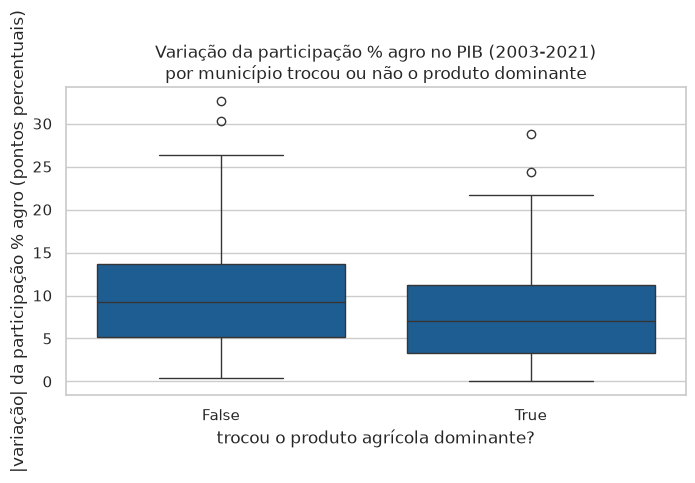

In [7]:
sns.boxplot(
    data=cruzamento_transformacao, x="mudou_produto_dominante", y="variacao_absoluta_participacao",
    color=AZUL,
)
plt.title("Variação da participação % agro no PIB (2003-2021)\npor município trocou ou não o produto dominante")
plt.xlabel("trocou o produto agrícola dominante?")
plt.ylabel("|variação| da participação % agro (pontos percentuais)")
plt.show()

Interpretação: compara a mediana/dispersão da variação de participação entre os dois grupos (mudou vs não mudou produto dominante). Se a mediana for visivelmente maior no grupo que mudou de produto, é indício de que transformação produtiva acompanha transformação da estrutura econômica — ainda associação, não causa, e com poucos municípios em cada grupo (verificar o `count` do `describe()` acima antes de generalizar).

## 5. Salvar em `analytical`

Tabela integrada, no grão município × ano, pronta pra ser consumida pelo dashboard sem precisar reprocessar as 3 bases originais.

In [8]:
merge_final.to_parquet("../dados/analytical/pib_pam_ppm_municipio_ano.parquet", index=False)